In [1]:
import json
import pandas as pd
import numpy as np

#data_path = '/mount/arbeitsdaten/studenten1/team-lab-phonetics/2023/student_directories/zeidler/too_big_for_git/preprocess/ALC_features_Functional.json'
# data_path = '/mount/arbeitsdaten/studenten1/team-lab-phonetics/2023/student_directories/zeidler/too_big_for_git/features/'

#should be same datasets, but they moved, so rerunning just in case
data_path = '/mount/arbeitsdaten/studenten1/team-lab-phonetics/2023/student_directories/zeidler/too_big_for_git/features/currently_used/filtered_class_balanced/'



In [2]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn import naive_bayes, svm
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix
import seaborn as sn
import matplotlib.pyplot as plt

In [3]:
# df = pd.read_json(data_path, orient='index')
# df.head()

In [4]:
# from sklearn.model_selection import train_test_split

# train, test = train_test_split(df, test_size=0.2)

In [5]:
import os
train_df = pd.read_json(os.path.join(data_path, 'filtered_features_balanced_Functional_train.json'), orient='index')
valid_df = pd.read_json(os.path.join(data_path, 'filtered_features_balanced_Functional_valid.json'), orient='index')
test_df = pd.read_json(os.path.join(data_path, 'filtered_features_balanced_Functional_test.json'), orient='index')

In [6]:
print (f'''Train contains {len(train_df)} examples.
Test contains {len(test_df)} examples. 
Valid contains {len(valid_df)} examples.''')

Train contains 7776 examples.
Test contains 972 examples. 
Valid contains 972 examples.


In [7]:
train_df['features'][0]

{'F0semitoneFrom27.5Hz_sma3nz_amean': [38.7604675293],
 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm': [0.1429889798],
 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0': [36.3585281372],
 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0': [38.1746025085],
 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0': [41.0310668945],
 'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2': [4.6725387573],
 'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope': [684.0389404297],
 'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope': [1181.0466308594],
 'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope': [213.8161468506],
 'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope': [329.6546020508],
 'loudness_sma3_amean': [0.2055649012],
 'loudness_sma3_stddevNorm': [1.0612789392],
 'loudness_sma3_percentile20.0': [0.036001008],
 'loudness_sma3_percentile50.0': [0.1311426461],
 'loudness_sma3_percentile80.0': [0.35147276520000004],
 'loudness_sma3_pctlrange0-2': [0.3154717684],
 'loudness_sma3_meanRisingSlope': [6.3048596382],
 'loudness_sma3_stddevRisin

In [8]:
train = train_df
valid = valid_df
test = test_df

# Majority Baseline 
(Just one dummy feature)

In [9]:
# this keeps one first feature -- should not be informative enough for the model to work
def features_to_vec(feature_dict):
#     out_vector = []
#     for feature in feature_dict.values():
#         out_vector.append(feature)
    return [0]

In [10]:
#check that it works and print the dimensions
print(f"The dataset has {len(train['features'])} data samples.")
print(f"Each data sample is a vector of {len(train['features'].apply(features_to_vec)[5])} dimensions.")

The dataset has 7776 data samples.
Each data sample is a vector of 1 dimensions.


In [11]:
label_to_idx = {"a":1, "cna":0, "na": 0}
X_train = train['features'].apply(features_to_vec).tolist() 
y_train = [label_to_idx[x] for x in train['intoxicated']]

# X_test = test['features'].apply(features_to_vec).tolist() 
# y_test = [label_to_idx[x] for x in test['intoxicated']]

X_test = valid['features'].apply(features_to_vec).tolist() 
y_test = [label_to_idx[x] for x in valid['intoxicated']]

In [12]:
def evaluate_classifier(classifier, X_test, y_test):
    y_predicted = classifier.predict(X_test)
    cm = confusion_matrix(y_test, y_predicted)
    sn.heatmap(cm, annot=True, fmt='g')
    plt.xlabel('Predicted')
    plt.ylabel('Expected')

In [13]:
X_train[2:4]
#look at this; maybe we could collapse redundant features? like do PCA or any other dimensionality reduction

[[0], [0]]

In [14]:
y_train[:2]

[0, 1]

In [15]:
X_train = np.array(X_train)
y_train = np.array(y_train)

In [16]:
nb_classifier = naive_bayes.BernoulliNB()
nb_classifier.fit(X_train, y_train)
accuracy = nb_classifier.score(X_test, y_test)
accuracy

0.45164609053497945

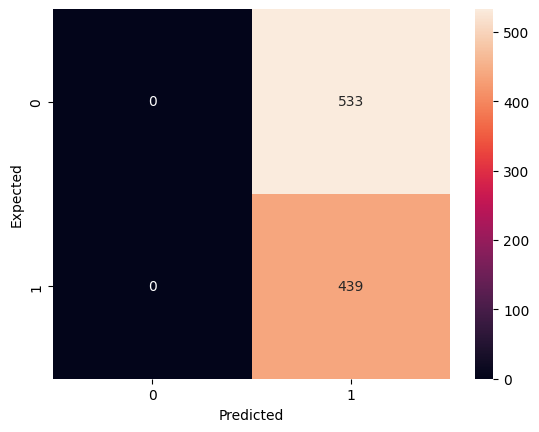

In [17]:
evaluate_classifier(nb_classifier, X_test, y_test)

# Actual Baseline

In [18]:
# this simply flattens all the features into one long concatenated vector
def features_to_vec(feature_dict):
    out_vector = []
    for feature in feature_dict.values():
        for subfeature in feature:
            out_vector.append(subfeature)
    return out_vector

features_to_vec(train['features'][0])

[38.7604675293,
 0.1429889798,
 36.3585281372,
 38.1746025085,
 41.0310668945,
 4.6725387573,
 684.0389404297,
 1181.0466308594,
 213.8161468506,
 329.6546020508,
 0.2055649012,
 1.0612789392,
 0.036001008,
 0.1311426461,
 0.35147276520000004,
 0.3154717684,
 6.3048596382,
 4.6772766113,
 4.9285273552,
 3.7070240974,
 0.0723346993,
 1.3926985264,
 10.5713043213,
 1.680731535,
 6.6310157776,
 1.9206192493,
 5.7504615784,
 2.0178749561,
 -1.2215695381,
 -11.1664171219,
 0.0245239008,
 1.4663728476,
 1.2811070681,
 1.015799284,
 8.6221427917,
 0.6672877073,
 11.0866498947,
 0.9546975493000001,
 21.3038768768,
 0.5712029338,
 614.5788574219,
 0.3893906176,
 1232.9710693359,
 0.2325440198,
 -146.6614685059,
 -0.5580168962000001,
 1661.2724609375,
 0.1392621845,
 887.1050415039,
 0.4508842826,
 -137.0375061035,
 -0.5954046249,
 2692.1884765625,
 0.1021484807,
 968.3168334961,
 0.6454965472,
 -138.3712158203,
 -0.5741513371,
 -12.8855066299,
 -0.8948621154,
 21.6045207977,
 0.6204605103,
 0.0

In [19]:
#check that it works and print the dimensions
print(f"The dataset has {len(train['features'])} data samples.")
print(f"Each data sample is a vector of {len(train['features'].apply(features_to_vec)[7])} dimensions.")

The dataset has 7776 data samples.
Each data sample is a vector of 88 dimensions.


In [20]:
label_to_idx = {"a":1, "cna":0, "na": 0}
X_train = train['features'].apply(features_to_vec).tolist() 
y_train = [label_to_idx[x] for x in train['intoxicated']]

X_test = test['features'].apply(features_to_vec).tolist() 
y_test = [label_to_idx[x] for x in test['intoxicated']]

In [21]:
def evaluate_classifier(classifier, X_test, y_test):
    y_predicted = classifier.predict(X_test)
    cm = confusion_matrix(y_test, y_predicted)
    sn.heatmap(cm, annot=True, fmt='g')
    plt.xlabel('Predicted')
    plt.ylabel('Expected')

In [22]:
#([set([type(x) for x in y]) for y in X_train])
X_train = np.array(X_train)
y_train = np.array(y_train)

In [23]:
nb_classifier = naive_bayes.BernoulliNB()
nb_classifier.fit(X_train, y_train)
accuracy = nb_classifier.score(X_test, y_test)
accuracy

0.5668724279835391

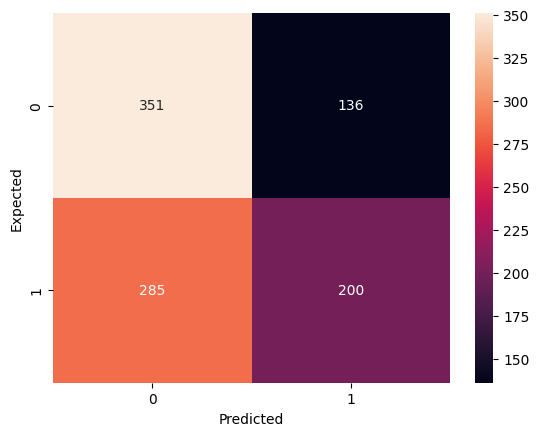

In [24]:
evaluate_classifier(nb_classifier, X_test, y_test)

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn import naive_bayes, svm 
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [26]:
knn_classifier = KNeighborsClassifier()
knn_classifier.fit(X_train, y_train)
accuracy = knn_classifier.score(X_test, y_test)
accuracy

0.5308641975308642

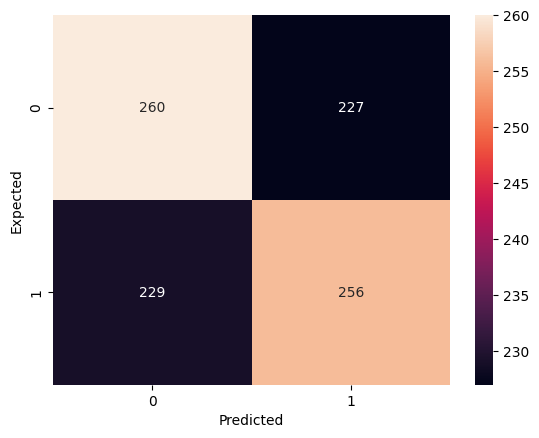

In [27]:
evaluate_classifier(knn_classifier, X_test, y_test)

In [28]:
rf_classifier = RandomForestClassifier()
rf_classifier.fit(X_train, y_train)
accuracy = rf_classifier.score(X_test, y_test)
accuracy 

0.6851851851851852

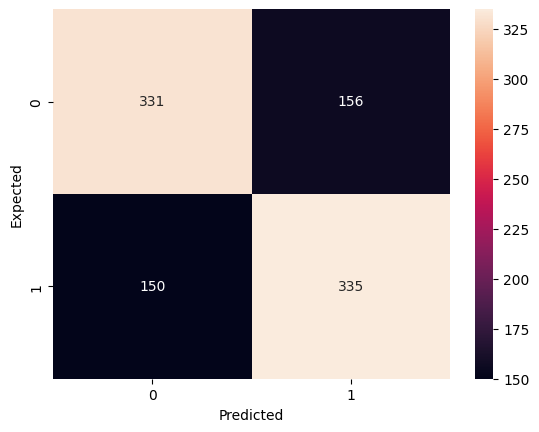

In [29]:
evaluate_classifier(rf_classifier, X_test, y_test)

In [30]:
svm_classifier = svm.LinearSVC()
svm_classifier.fit(X_train, y_train)
accuracy = svm_classifier.score(X_test, y_test)
accuracy

/mount/arbeitsdaten31/studenten1/team-lab-phonetics/2023/student_directories/kolos/NLP4/lib64/python3.10/site-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


0.5030864197530864

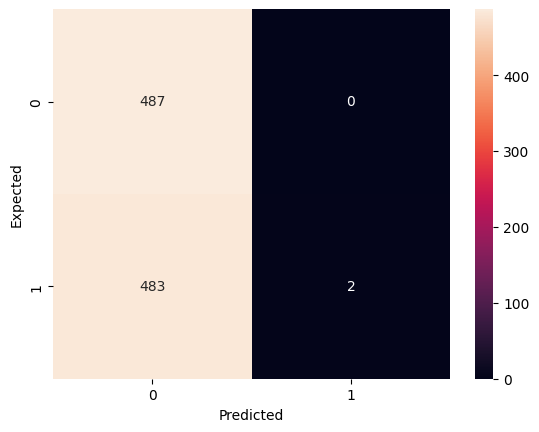

In [31]:
evaluate_classifier(svm_classifier, X_test, y_test)

In [32]:
svm_classifier = svm.NuSVC(kernel='poly')
svm_classifier.fit(X_train, y_train)
accuracy = svm_classifier.score(X_test, y_test)
accuracy

0.581275720164609

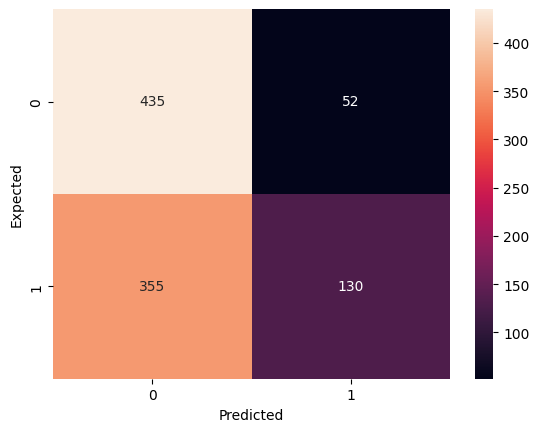

In [33]:
evaluate_classifier(svm_classifier, X_test, y_test)

In [34]:
logreg_classifier = LogisticRegression()
logreg_classifier.fit(X_train, y_train)
accuracy = logreg_classifier.score(X_test, y_test)
accuracy

/mount/arbeitsdaten31/studenten1/team-lab-phonetics/2023/student_directories/kolos/NLP4/lib64/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.5905349794238683

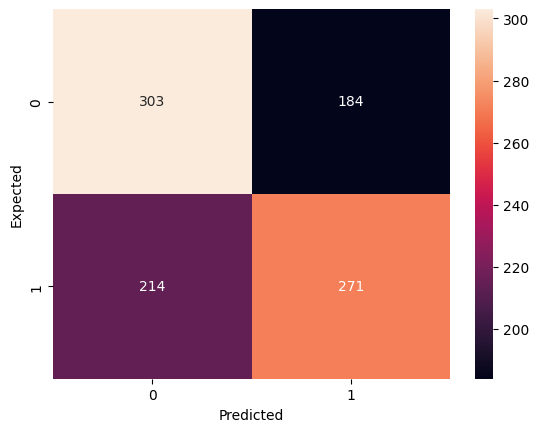

In [35]:
evaluate_classifier(logreg_classifier, X_test, y_test)

# Majority Baseline for the Levels (Regression Task)

In [36]:
from sklearn import linear_model

In [37]:
linmodel = linear_model.LinearRegression(fit_intercept=True)

In [38]:
def features_to_vec(feature_dict, i=0):
    out_vector = [list(feature_dict.values())[i][0]] #first of i-th feature only
    return out_vector

X_train = train['features'].apply(lambda x: features_to_vec(x, i=1)).tolist() 
X_test = test['features'].apply(lambda x: features_to_vec(x, i=1)).tolist() 
y_train = train['breath alcohol concentration']
y_test = test['breath alcohol concentration']
linmodel.fit(X_train, y_train)

LinearRegression()

In [39]:
(slope, intercept) = (linmodel.coef_[0], linmodel.intercept_)
print(slope, intercept)

-0.00012954200618195817 0.0004722450433762889


In [40]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))

Mean squared error: 0.00
Coefficient of determination: 0.00


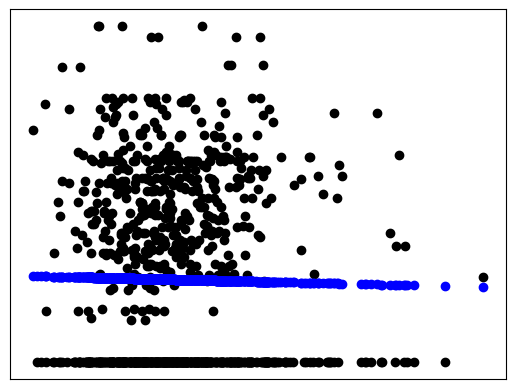

In [41]:
import matplotlib.pyplot as plt
# Plot outputs
#based on the one dimension of features
x_test_0 = [x[0] for x in X_test]

plt.scatter(x_test_0, y_test, color="black")
plt.scatter(x_test_0, y_pred, color="blue")
#plt.plot(x_test_0, y_pred, color="blue", linewidth=3)

plt.xticks(())
plt.yticks(())

plt.show()

In [42]:
#Find the feature that produces the best results (the best r2_score)
r2_score_max = -1
i_max = 0
for i in range(len(train['features'][0].keys())):
    linmodel = linear_model.LinearRegression(fit_intercept=True)
    X_train = train['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    X_test = test['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    y_train = train['breath alcohol concentration']
    y_test = test['breath alcohol concentration']
    linmodel.fit(X_train, y_train)
    y_pred = linmodel.predict(X_test)
    r2_score_cur = r2_score(y_test, y_pred)
    if r2_score_cur > r2_score_max:
        i_max = i
        r2_score_max = r2_score_cur

24 0.04135689045920432
Mean squared error: 0.00
Coefficient of determination: 0.04


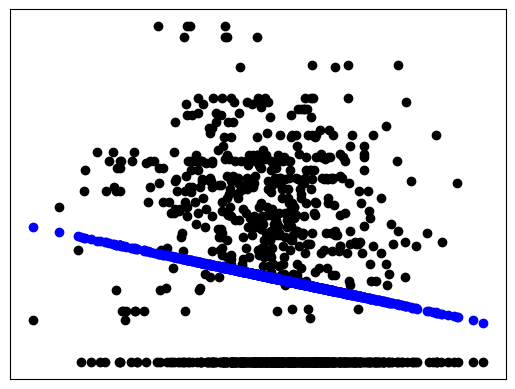

In [43]:
print(i_max, r2_score_max)

linmodel = linear_model.LinearRegression(fit_intercept=True)
X_train = train['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
X_test = test['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
y_train = train['breath alcohol concentration']
y_test = test['breath alcohol concentration']
linmodel.fit(X_train, y_train)
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))
plt.scatter(X_test, y_test, color="black")
plt.scatter(X_test, y_pred, color="blue")
plt.xticks(())
plt.yticks(())

plt.show()

## On only those who have non-0 alc level
### In the breath
Feature 38 seems to be correlated with the alcohol level in blood

24 0.04135689045920432
Mean squared error: 0.00
Coefficient of determination: 0.04


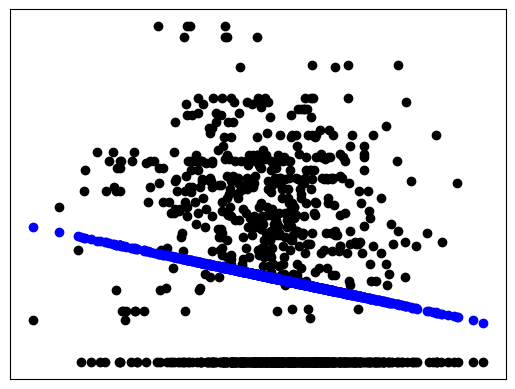

In [44]:
#Find the feature that produces the best results (the best r2_score)
r2_score_max = -1
i_max = 0
for i in range(len(train['features'][0].keys())):
    linmodel = linear_model.LinearRegression(fit_intercept=True)
    X_train = train['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    X_test = test['features'].apply(lambda x: features_to_vec(x, i=i)).tolist() 
    y_train = train['breath alcohol concentration']
    y_test = test['breath alcohol concentration']
    linmodel.fit(X_train, y_train)
    y_pred = linmodel.predict(X_test)
    r2_score_cur = r2_score(y_test, y_pred)
    if r2_score_cur > r2_score_max:
        i_max = i
        r2_score_max = r2_score_cur
        
print(i_max, r2_score_max)

linmodel = linear_model.LinearRegression(fit_intercept=True)
X_train = train['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
X_test = test['features'].apply(lambda x: features_to_vec(x, i=i_max)).tolist() 
y_train = train['breath alcohol concentration']
y_test = test['breath alcohol concentration']
linmodel.fit(X_train, y_train)
y_pred = linmodel.predict(X_test)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))
plt.scatter(X_test, y_test, color="black")
plt.scatter(X_test, y_pred, color="blue")
plt.xticks(())
plt.yticks(())

plt.show()

In [45]:
!pwd

/mount/arbeitsdaten31/studenten1/team-lab-phonetics/2023/student_directories/kolos/CLTeamLab/intoxicat/baselines
